In [2]:
import os
import cv2
import numpy as np
import pandas as pd

from tqdm import tqdm

from scipy.stats import entropy

import matplotlib.pyplot as plt
import seaborn as sns

TRAIN_DIR = "data/train"
CSV_PATH = "train.csv"

df = pd.read_csv(CSV_PATH)

label_to_folder = {
    0: "dark",
    1: "normal",
    2: "bright"
}

df["image_path"] = df.apply(
    lambda row: os.path.join(
        TRAIN_DIR,
        label_to_folder[row["label"]],
        row["id"] + ".png"
    ),
    axis=1
)

df.head()

,id,label,image_path
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,data/train/dark/02137a86-0743-40e0-845b-6d22d1...
1,025d39a8-7859-4558-9bf9-bbdd475c6100,0,data/train/dark/025d39a8-7859-4558-9bf9-bbdd47...
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0,data/train/dark/02a2a878-c5a4-490a-8061-6b2f4a...
3,047f7996-9f0d-4a04-ae7f-24e246c407c7,0,data/train/dark/047f7996-9f0d-4a04-ae7f-24e246...
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0,data/train/dark/052a9d62-a31f-4e4f-9a76-edac2d...


In [3]:
print(df.shape)

print(df.head())

print(os.path.exists(df.iloc[0]["image_path"]))

(1500, 3)
                                     id  label  \
0  02137a86-0743-40e0-845b-6d22d1d5cc85      0   
1  025d39a8-7859-4558-9bf9-bbdd475c6100      0   
2  02a2a878-c5a4-490a-8061-6b2f4ac3b6d0      0   
3  047f7996-9f0d-4a04-ae7f-24e246c407c7      0   
4  052a9d62-a31f-4e4f-9a76-edac2d2ae95d      0   

                                          image_path  
0  data/train/dark/02137a86-0743-40e0-845b-6d22d1...  
1  data/train/dark/025d39a8-7859-4558-9bf9-bbdd47...  
2  data/train/dark/02a2a878-c5a4-490a-8061-6b2f4a...  
3  data/train/dark/047f7996-9f0d-4a04-ae7f-24e246...  
4  data/train/dark/052a9d62-a31f-4e4f-9a76-edac2d...  
True


### Handcrafted Feature Function

In [4]:
def extract_handcrafted_features(image_path):

    image = cv2.imread(image_path)

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)

    lab = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)

    features = {}

    # -------------------
    # Gray Statistics
    # -------------------

    features["mean_gray"] = np.mean(gray)

    features["median_gray"] = np.median(gray)

    features["std_gray"] = np.std(gray)

    features["min_gray"] = np.min(gray)

    features["max_gray"] = np.max(gray)

    features["contrast"] = np.std(gray)

    # -------------------
    # Histogram Entropy
    # -------------------

    hist = cv2.calcHist(
        [gray],
        [0],
        None,
        [256],
        [0,256]
    )

    hist = hist.ravel()

    hist = hist / hist.sum()

    features["entropy"] = entropy(hist)

    # -------------------
    # HSV
    # -------------------

    features["h_mean"] = hsv[:,:,0].mean()

    features["s_mean"] = hsv[:,:,1].mean()

    features["v_mean"] = hsv[:,:,2].mean()

    features["h_std"] = hsv[:,:,0].std()

    features["s_std"] = hsv[:,:,1].std()

    features["v_std"] = hsv[:,:,2].std()

    # -------------------
    # LAB
    # -------------------

    features["l_mean"] = lab[:,:,0].mean()

    features["a_mean"] = lab[:,:,1].mean()

    features["b_mean"] = lab[:,:,2].mean()

    features["l_std"] = lab[:,:,0].std()

    features["a_std"] = lab[:,:,1].std()

    features["b_std"] = lab[:,:,2].std()

    # -------------------
    # Edge Density
    # -------------------

    edges = cv2.Canny(gray,100,200)

    features["edge_density"] = np.mean(edges > 0)

    # -------------------
    # Sharpness
    # -------------------

    features["laplacian_var"] = cv2.Laplacian(
        gray,
        cv2.CV_64F
    ).var()

    # -------------------
    # Bright/Dark Pixels
    # -------------------

    features["bright_ratio"] = np.mean(gray > 200)

    features["dark_ratio"] = np.mean(gray < 50)

    return features

### Test on One Image First

In [5]:
sample = extract_handcrafted_features(df.iloc[0]["image_path"])

print(sample)
print()
print("Number of Features:", len(sample))

{'mean_gray': np.float64(73.14991760253906), 'median_gray': np.float64(65.0), 'std_gray': np.float64(41.622513624661174), 'min_gray': np.uint8(0), 'max_gray': np.uint8(194), 'contrast': np.float64(41.622513624661174), 'entropy': np.float32(5.032064), 'h_mean': np.float64(41.816593170166016), 's_mean': np.float64(75.5879020690918), 'v_mean': np.float64(78.05232620239258), 'h_std': np.float64(34.944003568606554), 's_std': np.float64(56.40569633478858), 'v_std': np.float64(41.44069070129419), 'l_mean': np.float64(78.25395965576172), 'a_mean': np.float64(125.86444473266602), 'b_mean': np.float64(135.2985496520996), 'l_std': np.float64(45.37138503163153), 'a_std': np.float64(4.454920161213781), 'b_std': np.float64(5.600768257500514), 'edge_density': np.float64(0.0120697021484375), 'laplacian_var': np.float64(219.4836287828948), 'bright_ratio': np.float64(0.0), 'dark_ratio': np.float64(0.3470802307128906)}

Number of Features: 23


### Extract Features from Entire Dataset

In [6]:
feature_list = []

for _, row in tqdm(df.iterrows(), total=len(df)):

    features = extract_handcrafted_features(row["image_path"])

    features["id"] = row["id"]
    features["label"] = row["label"]

    feature_list.append(features)

handcrafted_df = pd.DataFrame(feature_list)

handcrafted_df.head()

100%|██████████| 1500/1500 [00:35<00:00, 42.76it/s]


,mean_gray,median_gray,std_gray,min_gray,max_gray,contrast,entropy,h_mean,s_mean,v_mean,...,b_mean,l_std,a_std,b_std,edge_density,laplacian_var,bright_ratio,dark_ratio,id,label
0,73.149918,65.0,41.622514,0,194,41.622514,5.032064,41.816593,75.587902,78.052326,...,135.298550,45.371385,4.454920,5.600768,0.012070,219.483629,0.000000,0.347080,02137a86-0743-40e0-845b-6d22d1d5cc85,0
1,71.039921,74.0,35.679528,0,198,35.679528,4.856895,50.898388,60.281879,75.315220,...,133.852314,39.861752,4.374290,3.988359,0.018215,229.052303,0.000000,0.272717,025d39a8-7859-4558-9bf9-bbdd475c6100,0
2,96.133110,91.0,48.008489,6,232,48.008489,5.073146,27.287617,75.138744,104.939178,...,138.830452,49.641611,4.502393,5.323365,0.035538,281.944820,0.055027,0.188370,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0
3,44.125774,37.5,26.340371,2,185,26.340371,4.457826,76.591228,100.453033,50.624302,...,129.895306,30.074583,4.816540,6.653980,0.020493,237.096365,0.000000,0.674461,047f7996-9f0d-4a04-ae7f-24e246c407c7,0
4,52.545132,44.0,30.152093,0,157,30.152093,4.424922,60.715370,111.251938,61.120087,...,136.325592,34.338513,6.066670,4.152095,0.010010,225.819341,0.000000,0.628185,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0


In [7]:
print(handcrafted_df.shape)

handcrafted_df.head()

(1500, 25)


,mean_gray,median_gray,std_gray,min_gray,max_gray,contrast,entropy,h_mean,s_mean,v_mean,...,b_mean,l_std,a_std,b_std,edge_density,laplacian_var,bright_ratio,dark_ratio,id,label
0,73.149918,65.0,41.622514,0,194,41.622514,5.032064,41.816593,75.587902,78.052326,...,135.298550,45.371385,4.454920,5.600768,0.012070,219.483629,0.000000,0.347080,02137a86-0743-40e0-845b-6d22d1d5cc85,0
1,71.039921,74.0,35.679528,0,198,35.679528,4.856895,50.898388,60.281879,75.315220,...,133.852314,39.861752,4.374290,3.988359,0.018215,229.052303,0.000000,0.272717,025d39a8-7859-4558-9bf9-bbdd475c6100,0
2,96.133110,91.0,48.008489,6,232,48.008489,5.073146,27.287617,75.138744,104.939178,...,138.830452,49.641611,4.502393,5.323365,0.035538,281.944820,0.055027,0.188370,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0
3,44.125774,37.5,26.340371,2,185,26.340371,4.457826,76.591228,100.453033,50.624302,...,129.895306,30.074583,4.816540,6.653980,0.020493,237.096365,0.000000,0.674461,047f7996-9f0d-4a04-ae7f-24e246c407c7,0
4,52.545132,44.0,30.152093,0,157,30.152093,4.424922,60.715370,111.251938,61.120087,...,136.325592,34.338513,6.066670,4.152095,0.010010,225.819341,0.000000,0.628185,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0


In [8]:
handcrafted_df.to_csv(
    "handcrafted_features.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully


In [9]:
print(handcrafted_df.isnull().sum())

print("\nTotal Missing Values:", handcrafted_df.isnull().sum().sum())

mean_gray        0
median_gray      0
std_gray         0
min_gray         0
max_gray         0
contrast         0
entropy          0
h_mean           0
s_mean           0
v_mean           0
h_std            0
s_std            0
v_std            0
l_mean           0
a_mean           0
b_mean           0
l_std            0
a_std            0
b_std            0
edge_density     0
laplacian_var    0
bright_ratio     0
dark_ratio       0
id               0
label            0
dtype: int64

Total Missing Values: 0


In [10]:
# Statistical Summary
handcrafted_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mean_gray,1500.0,75.292999,20.266499,15.653549,61.221719,74.576588,89.155041,161.094166
median_gray,1500.0,72.519000,25.521162,14.000000,54.000000,72.000000,90.000000,182.000000
std_gray,1500.0,41.056775,9.802184,7.453714,34.717221,40.492406,47.354802,74.793261
min_gray,1500.0,1.633333,3.718258,0.000000,0.000000,0.000000,1.000000,50.000000
max_gray,1500.0,192.696000,23.599468,104.000000,178.000000,194.000000,210.000000,239.000000
contrast,1500.0,41.056775,9.802184,7.453714,34.717221,40.492406,47.354802,74.793261
entropy,1500.0,4.816695,0.265284,3.342456,4.677202,4.853716,5.009585,5.354904
h_mean,1500.0,49.894698,12.896626,24.822998,40.476230,47.766544,57.550453,103.989258
s_mean,1500.0,83.093263,24.993131,22.918007,64.677303,80.614197,97.132525,180.648060
v_mean,1500.0,81.978729,21.012601,19.482277,67.203616,81.168482,96.220205,171.477669


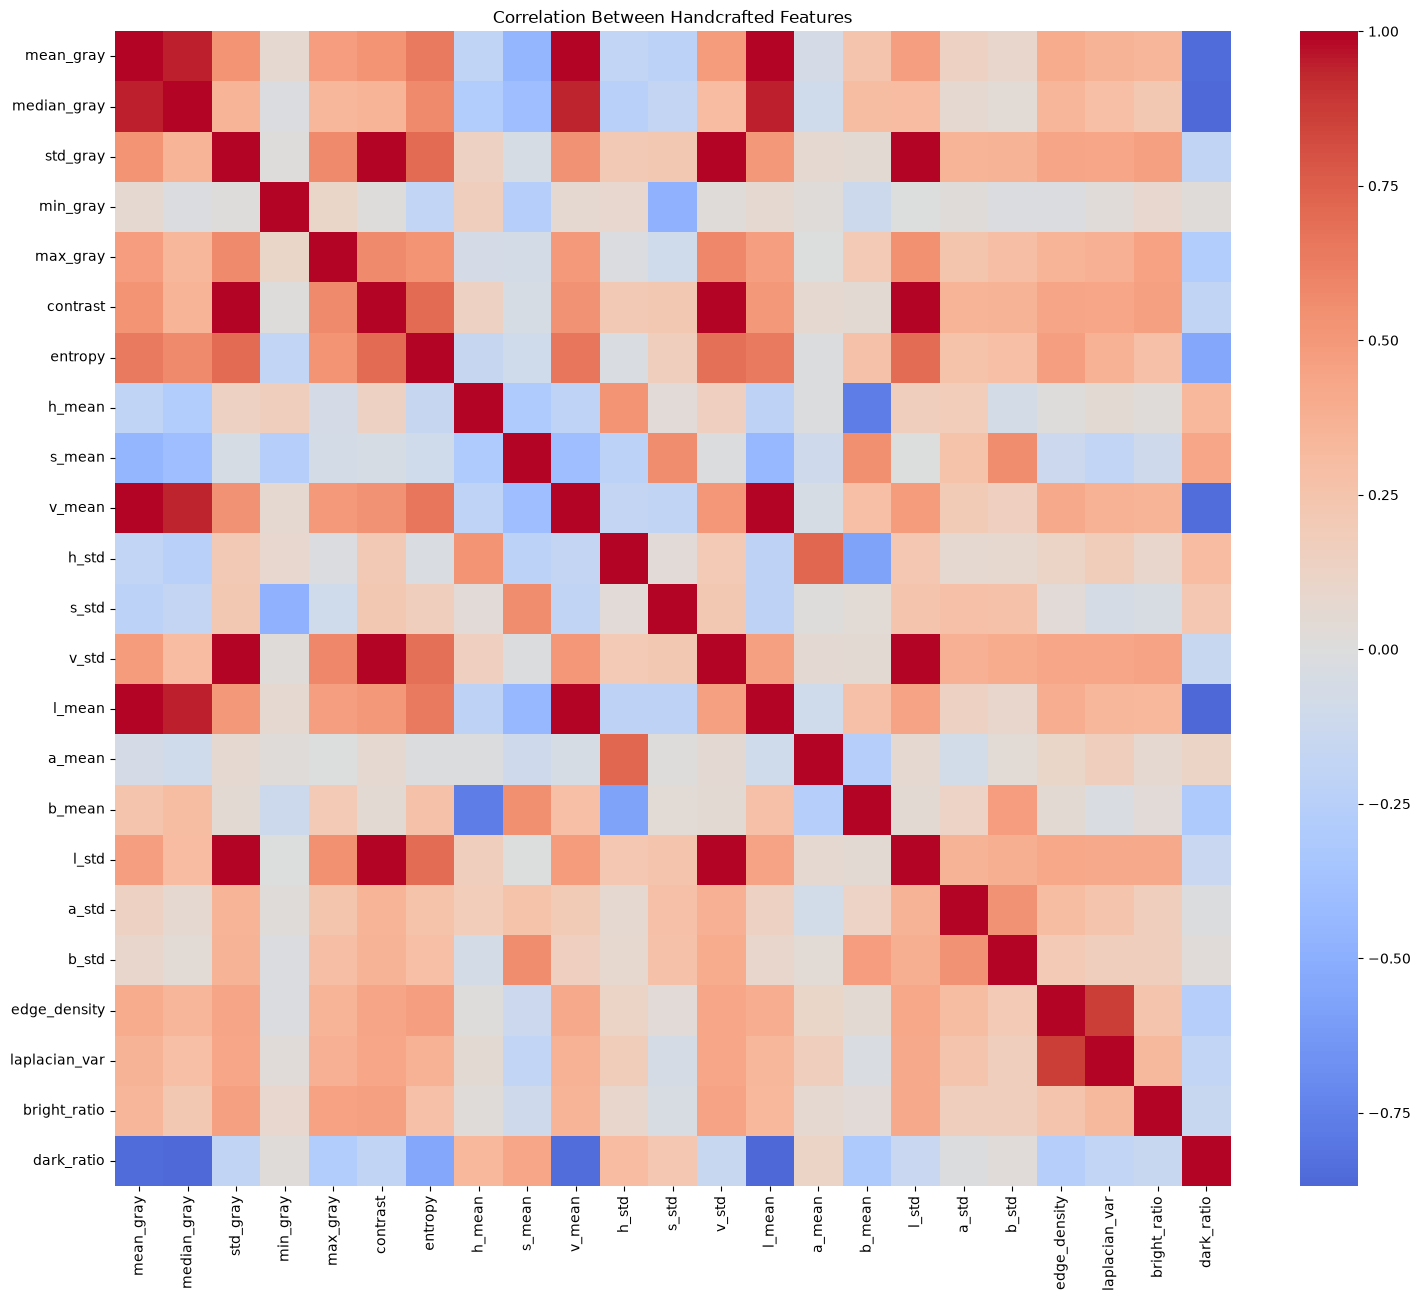

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18,15))

corr = handcrafted_df.drop(columns=["id","label"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Between Handcrafted Features")

plt.show()

### ANOVA Feature Ranking

In [12]:
from sklearn.feature_selection import f_classif

X = handcrafted_df.drop(columns=["id","label"])
y = handcrafted_df["label"]

F, p = f_classif(X, y)

anova_df = pd.DataFrame({
    "Feature": X.columns,
    "F_score": F,
    "p_value": p
})

anova_df = anova_df.sort_values(
    by="F_score",
    ascending=False
)

anova_df

,Feature,F_score,p_value
22,dark_ratio,154.653506,8.811080e-62
13,l_mean,143.063908,1.391346e-57
1,median_gray,138.920722,4.545545e-56
9,v_mean,137.595584,1.391097e-55
0,mean_gray,137.480457,1.533188e-55
6,entropy,55.193709,7.452037e-24
8,s_mean,29.059618,4.153297e-13
19,edge_density,25.698115,1.063560e-11
7,h_mean,19.274862,5.432507e-09
15,b_mean,17.268702,3.850377e-08


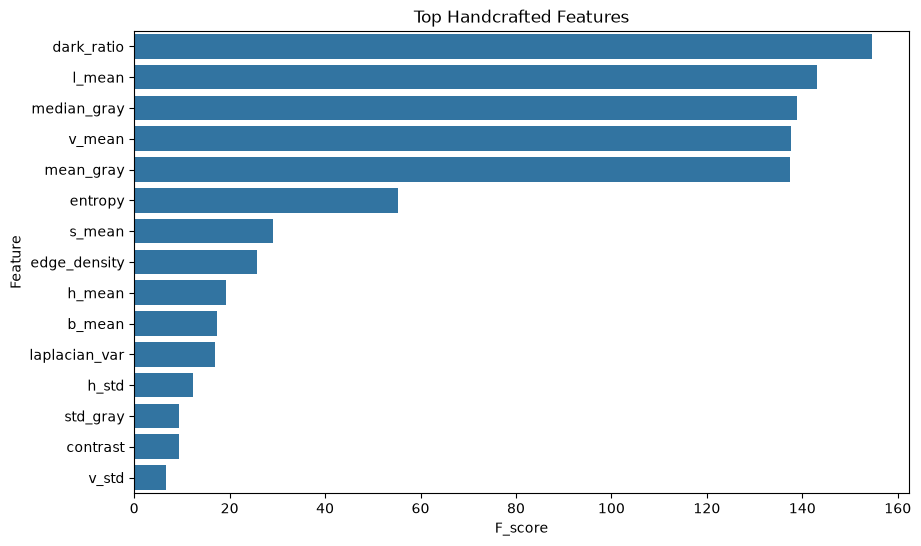

In [13]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=anova_df.head(15),
    x="F_score",
    y="Feature"
)

plt.title("Top Handcrafted Features")

plt.show()

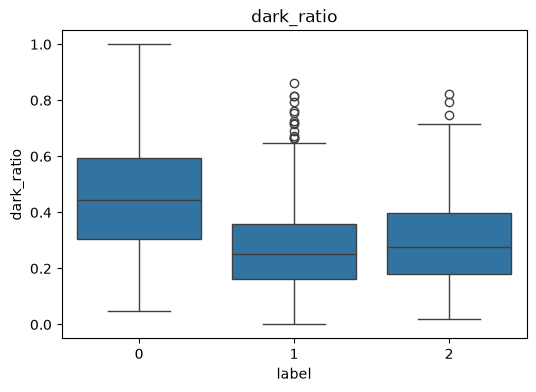

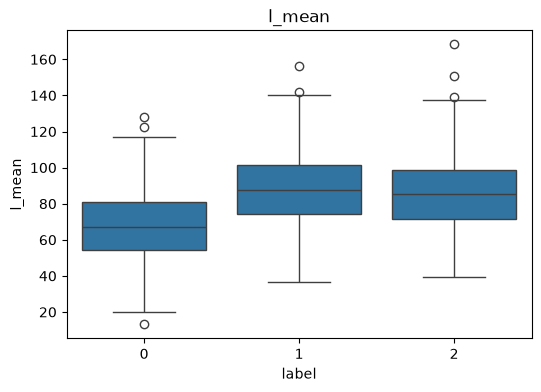

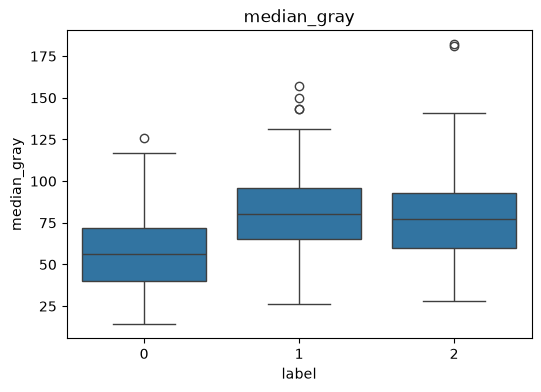

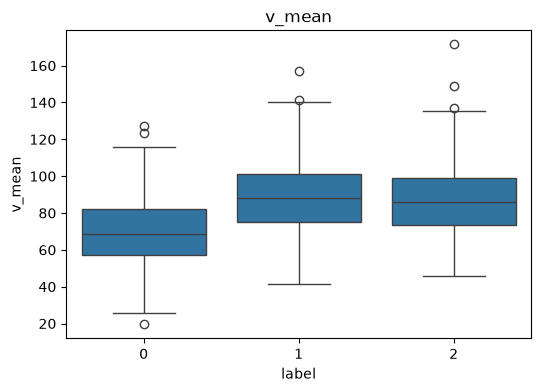

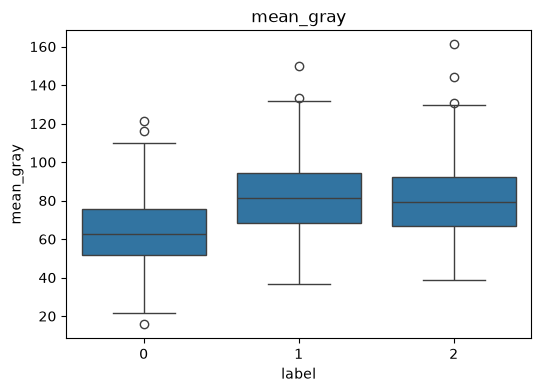

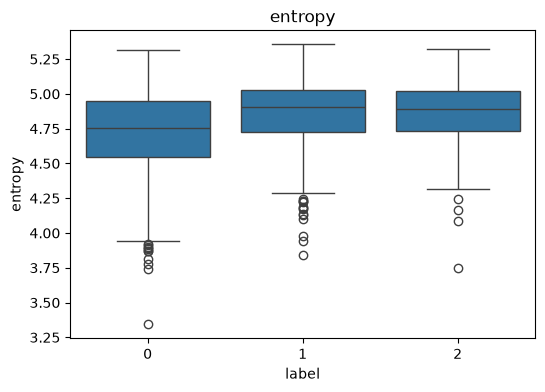

In [14]:
top_features = anova_df.head(6)["Feature"]

for feature in top_features:

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=handcrafted_df,
        x="label",
        y=feature
    )

    plt.title(feature)

    plt.show()

# Build the Hybrid Dataset

### Load ResNet Features

In [15]:
resnet_df = pd.read_csv("resnet_features.csv")

print(resnet_df.shape)

resnet_df.head()

(1500, 514)


,image,label,resnet_0,resnet_1,resnet_2,resnet_3,resnet_4,resnet_5,resnet_6,resnet_7,...,resnet_502,resnet_503,resnet_504,resnet_505,resnet_506,resnet_507,resnet_508,resnet_509,resnet_510,resnet_511
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,1.503252,0.733779,1.513309,0.041626,1.466865,1.763368,0.650255,1.772707,...,1.685473,0.089838,0.565075,1.063030,0.742253,0.548735,0.977023,0.234568,1.384308,0.575205
1,025d39a8-7859-4558-9bf9-bbdd475c6100,0,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,...,0.279744,0.618367,0.540192,3.436490,2.076207,0.436047,0.290990,1.178626,0.741967,0.428287
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,...,0.877449,0.399507,0.964876,1.779683,0.078416,0.693545,0.508940,0.199606,0.018365,0.465379
3,047f7996-9f0d-4a04-ae7f-24e246c407c7,0,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,...,1.335343,0.806069,1.044957,1.080118,0.747630,0.015274,0.673897,0.666867,0.717901,0.218544
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,...,0.982408,0.407484,0.560537,0.850064,0.370739,0.031080,0.542728,0.668791,0.933221,0.123311


In [19]:
resnet_df = resnet_df.rename(columns={"image": "id"})


print(handcrafted_df["id"].equals(resnet_df["id"]))

True


In [17]:
print(resnet_df.columns.tolist())

['image', 'label', 'resnet_0', 'resnet_1', 'resnet_2', 'resnet_3', 'resnet_4', 'resnet_5', 'resnet_6', 'resnet_7', 'resnet_8', 'resnet_9', 'resnet_10', 'resnet_11', 'resnet_12', 'resnet_13', 'resnet_14', 'resnet_15', 'resnet_16', 'resnet_17', 'resnet_18', 'resnet_19', 'resnet_20', 'resnet_21', 'resnet_22', 'resnet_23', 'resnet_24', 'resnet_25', 'resnet_26', 'resnet_27', 'resnet_28', 'resnet_29', 'resnet_30', 'resnet_31', 'resnet_32', 'resnet_33', 'resnet_34', 'resnet_35', 'resnet_36', 'resnet_37', 'resnet_38', 'resnet_39', 'resnet_40', 'resnet_41', 'resnet_42', 'resnet_43', 'resnet_44', 'resnet_45', 'resnet_46', 'resnet_47', 'resnet_48', 'resnet_49', 'resnet_50', 'resnet_51', 'resnet_52', 'resnet_53', 'resnet_54', 'resnet_55', 'resnet_56', 'resnet_57', 'resnet_58', 'resnet_59', 'resnet_60', 'resnet_61', 'resnet_62', 'resnet_63', 'resnet_64', 'resnet_65', 'resnet_66', 'resnet_67', 'resnet_68', 'resnet_69', 'resnet_70', 'resnet_71', 'resnet_72', 'resnet_73', 'resnet_74', 'resnet_75', 're

In [18]:
print(resnet_df["image"].head())

print(handcrafted_df["id"].head())

0    02137a86-0743-40e0-845b-6d22d1d5cc85
1    025d39a8-7859-4558-9bf9-bbdd475c6100
2    02a2a878-c5a4-490a-8061-6b2f4ac3b6d0
3    047f7996-9f0d-4a04-ae7f-24e246c407c7
4    052a9d62-a31f-4e4f-9a76-edac2d2ae95d
Name: image, dtype: str
0    02137a86-0743-40e0-845b-6d22d1d5cc85
1    025d39a8-7859-4558-9bf9-bbdd475c6100
2    02a2a878-c5a4-490a-8061-6b2f4ac3b6d0
3    047f7996-9f0d-4a04-ae7f-24e246c407c7
4    052a9d62-a31f-4e4f-9a76-edac2d2ae95d
Name: id, dtype: str


### merze

In [20]:
hybrid_df = pd.merge(
    resnet_df,
    handcrafted_df,
    on=["id", "label"],
    how="inner"
)

print(hybrid_df.shape)

hybrid_df.head()

(1500, 537)


,id,label,resnet_0,resnet_1,resnet_2,resnet_3,resnet_4,resnet_5,resnet_6,resnet_7,...,l_mean,a_mean,b_mean,l_std,a_std,b_std,edge_density,laplacian_var,bright_ratio,dark_ratio
0,02137a86-0743-40e0-845b-6d22d1d5cc85,0,1.503252,0.733779,1.513309,0.041626,1.466865,1.763368,0.650255,1.772707,...,78.253960,125.864445,135.298550,45.371385,4.454920,5.600768,0.012070,219.483629,0.000000,0.347080
1,025d39a8-7859-4558-9bf9-bbdd475c6100,0,1.567873,1.037666,0.364339,0.587060,1.974926,1.137942,0.527725,0.449724,...,76.909702,123.298275,133.852314,39.861752,4.374290,3.988359,0.018215,229.052303,0.000000,0.272717
2,02a2a878-c5a4-490a-8061-6b2f4ac3b6d0,0,0.411265,1.356105,1.317105,0.094091,0.854148,0.370707,0.005329,0.210806,...,102.359478,128.527328,138.830452,49.641611,4.502393,5.323365,0.035538,281.944820,0.055027,0.188370
3,047f7996-9f0d-4a04-ae7f-24e246c407c7,0,1.107608,3.403687,1.248990,0.789486,0.320989,2.138436,2.261848,1.083504,...,47.191967,122.214401,129.895306,30.074583,4.816540,6.653980,0.020493,237.096365,0.000000,0.674461
4,052a9d62-a31f-4e4f-9a76-edac2d2ae95d,0,1.085853,1.090163,1.399769,1.643254,0.359540,0.761260,0.610737,1.538106,...,58.798435,116.122681,136.325592,34.338513,6.066670,4.152095,0.010010,225.819341,0.000000,0.628185


In [21]:
print("Rows :", hybrid_df.shape[0])
print("Columns :", hybrid_df.shape[1])

print("Duplicate IDs :", hybrid_df["id"].duplicated().sum())

print("Missing Values :", hybrid_df.isnull().sum().sum())

Rows : 1500
Columns : 537
Duplicate IDs : 0
Missing Values : 0


In [22]:
hybrid_df.to_csv("hybrid_features.csv", index=False)